In [153]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import pickle

In [154]:
df1 = pd.read_csv('train.csv')
df1

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [155]:
df1.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
752,753,0,3,"Vande Velde, Mr. Johannes Joseph",male,33.0,0,0,345780,9.50,NaN,S
51,52,0,3,"Nosworthy, Mr. Richard Cater",male,21.0,0,0,A/4. 39886,7.80,NaN,S
546,547,1,2,"Beane, Mrs. Edward (Ethel Clarke)",female,19.0,1,0,2908,26.00,NaN,S
741,742,0,1,"Cavendish, Mr. Tyrell William",male,36.0,1,0,19877,78.85,C46,S
345,346,1,2,"Brown, Miss. Amelia ""Mildred""",female,24.0,0,0,248733,13.00,F33,S


In [156]:

#fancy indexing
# df1['Sex'] = df1['Sex'].map({'male' : 1,'female' : 0,})

# df1.drop(['PassengerId','Name','Ticket','Cabin'], axis=1, inplace=True)

# df1.sample(4)

In [157]:
# we are gonna do one hot ewncoding on nominal data like sex 

In [158]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [159]:
# df1['Embarked'] = df1['Embarked'].str.strip()
# df1['Embarked'] = df1['Embarked'].map({'S' : 0,'C' : 1,'Q' : 2,              })
df1.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
548,549,0,3,"Goldsmith, Mr. Frank John",male,33.0,1,1,363291,20.5250,NaN,S
775,776,0,3,"Myhrman, Mr. Pehr Fabian Oliver Malkolm",male,18.0,0,0,347078,7.7500,NaN,S
474,475,0,3,"Strandberg, Miss. Ida Sofia",female,22.0,0,0,7553,9.8375,NaN,S
391,392,1,3,"Jansson, Mr. Carl Olof",male,21.0,0,0,350034,7.7958,NaN,S


In [160]:
# we are gonna do one hot encoding on the nomial data like 

<Axes: >

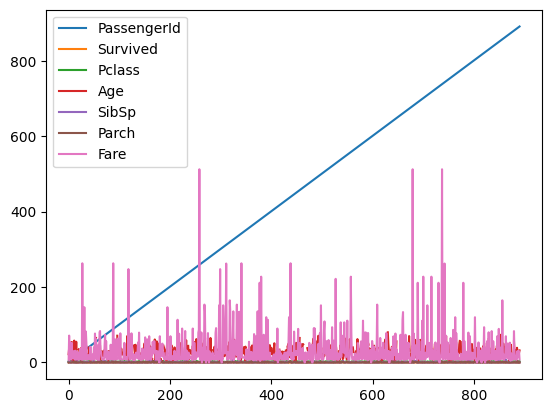

In [161]:
df1.plot()

In [162]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [163]:
# brute force lol df1.dropna(inplace=True)
#checking each column now to improve accuracy :(
    
from numpy import median
from math import ceil

df1['Age'] = df1['Age'].fillna(df1['Age'].mean())#mean is giving more accuracy than median 
df1['Embarked'] = df1['Embarked'].fillna(df1['Embarked'].mode()[0])

#ony age and embarked has missing lol


In [164]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [165]:
df1.shape[0]

891

In [166]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [167]:
df1.drop(['Ticket','Cabin'], axis=1, inplace=True)
titanic_train_input = df1.iloc[:,2:]
titanic_train_output = df1.iloc[:,1]
titanic_train_input.sample(5)

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
694,1,"Weir, Col. John",male,60.000000,0,0,26.55,S
17,2,"Williams, Mr. Charles Eugene",male,29.699118,0,0,13.00,S
250,3,"Reed, Mr. James George",male,29.699118,0,0,7.25,S
740,1,"Hawksford, Mr. Walter James",male,29.699118,0,0,30.00,S
323,2,"Caldwell, Mrs. Albert Francis (Sylvia Mae Harb...",female,22.000000,1,1,29.00,S


In [168]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Fare         891 non-null    float64
 9   Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(3)
memory usage: 69.7 KB


In [169]:
#here is ohe on sex on both training and testing  
# ohe = OneHotEncoder(sparse_output=False, dtype=np.int32)
# titanic_train_sex = ohe.fit_transform(titanic_train_input[['Sex']])
# titanic_train_input.drop(['Sex'],inplace=True,axis=1)
# titanic_train_input = np.hstack((titanic_train_input,titanic_train_sex))
# titanic_train_input


In [170]:
titanic_train_output.sample(5)

72     0
868    0
871    1
372    0
800    0
Name: Survived, dtype: int64

In [171]:
from sklearn.model_selection import train_test_split

In [172]:
#x is input / inputs
#y is output 

x_train,x_test,y_train,y_test= train_test_split(titanic_train_input,titanic_train_output,test_size=0.25,random_state=42)

In [173]:
x_train

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
298,1,"Saalfeld, Mr. Adolphe",male,29.699118,0,0,30.5000,S
884,3,"Sutehall, Mr. Henry Jr",male,25.000000,0,0,7.0500,S
247,2,"Hamalainen, Mrs. William (Anna)",female,24.000000,0,2,14.5000,S
478,3,"Karlsson, Mr. Nils August",male,22.000000,0,0,7.5208,S
305,1,"Allison, Master. Hudson Trevor",male,0.920000,1,2,151.5500,S
...,...,...,...,...,...,...,...,...
106,3,"Salkjelsvik, Miss. Anna Kristine",female,21.000000,0,0,7.6500,S
270,1,"Cairns, Mr. Alexander",male,29.699118,0,0,31.0000,S
860,3,"Hansen, Mr. Claus Peter",male,41.000000,2,0,14.1083,S
435,1,"Carter, Miss. Lucile Polk",female,14.000000,1,2,120.0000,S


In [174]:
y_train.shape

(668,)

In [175]:
y_test

709    1
439    0
840    0
720    1
39     1
      ..
880    1
425    0
101    0
199    0
424    0
Name: Survived, Length: 223, dtype: int64

In [176]:
x_train["Title"] = x_train["Name"].str.extract(r',\s*([^\.]+)\.')

allowed_titles = ["Mr", "Mrs", "Miss", "Master"]

x_train["Title"] = x_train["Title"].apply(
    lambda x: x if x in allowed_titles else "Rare"
)
x_test["Title"] = x_test["Name"].str.extract(r',\s*([^\.]+)\.')

allowed_titles = ["Mr", "Mrs", "Miss", "Master"]

x_test["Title"] = x_test["Title"].apply(
    lambda x: x if x in allowed_titles else "Rare"
)

In [177]:
x_train.drop(['Name'],axis=1,inplace=True)
x_test.drop(['Name'],axis=1,inplace=True)

In [178]:
x_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
709,3,male,29.699118,1,1,15.2458,C,Master
439,2,male,31.000000,0,0,10.5000,S,Mr
840,3,male,20.000000,0,0,7.9250,S,Mr
720,2,female,6.000000,0,1,33.0000,S,Miss
39,3,female,14.000000,1,0,11.2417,C,Miss
...,...,...,...,...,...,...,...,...
880,2,female,25.000000,0,1,26.0000,S,Mrs
425,3,male,29.699118,0,0,7.2500,S,Mr
101,3,male,29.699118,0,0,7.8958,S,Mr
199,2,female,24.000000,0,0,13.0000,S,Miss


In [179]:
x_test = pd.get_dummies(x_test,columns=['Sex','Embarked','Title'],drop_first=True,dtype=np.int32)
x_train = pd.get_dummies(x_train,columns=['Sex','Embarked','Title'],drop_first=True,dtype=np.int32)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() 
x_train_Transformed = scaler.fit_transform(x_train)


In [180]:
x_test

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
709,3,29.699118,1,1,15.2458,1,0,0,0,0,0,0
439,2,31.000000,0,0,10.5000,1,0,1,0,1,0,0
840,3,20.000000,0,0,7.9250,1,0,1,0,1,0,0
720,2,6.000000,0,1,33.0000,0,0,1,1,0,0,0
39,3,14.000000,1,0,11.2417,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
880,2,25.000000,0,1,26.0000,0,0,1,0,0,1,0
425,3,29.699118,0,0,7.2500,1,0,1,0,1,0,0
101,3,29.699118,0,0,7.8958,1,0,1,0,1,0,0
199,2,24.000000,0,0,13.0000,0,0,1,1,0,0,0


In [181]:
print(x_train.columns.tolist())
print(x_test.columns.tolist())

['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']


In [182]:
x_test = scaler.transform(x_test)

In [183]:
print(x_train.columns.tolist())

['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']


In [184]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(x_train_Transformed,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [185]:
y_pred = clf.predict(x_test)

In [186]:
y_pred.shape

(223,)

In [187]:
y_test.shape

(223,)

In [188]:
from sklearn.metrics import precision_score,accuracy_score

In [189]:
accuracy_score(y_test,y_pred)

0.8116591928251121

In [190]:
precision_score(y_test,y_pred)

0.7640449438202247

In [191]:
# df2 = pd.read_csv('test.csv')
# df2.sample(5)
# passenger_ids = df2['PassengerId']

In [192]:
# df2.drop(['PassengerId','Ticket','Cabin'],axis=1,inplace=True)
# df2.sample(5)


In [193]:
# df2.plot()

In [194]:
# df2['Age'] = df2['Age'].fillna(df1['Age'].mean())

# titanic_test = df2
# titanic_test["Title"] = titanic_test["Name"].str.extract(r',\s*([^\.]+)\.')

# allowed_titles = ["Mr", "Mrs", "Miss", "Master"]
# # 
# titanic_test["Title"] = titanic_test["Title"].apply(
#     lambda x: x if x in allowed_titles else "Rare"
# )


In [195]:
# titanic_test.info()

In [196]:
# # titanic_test['Fare'] = titanic_test['Fare'].fillna(df1['Fare'].median())
# titanic_test = pd.get_dummies(titanic_test,columns=['Sex','Embarked','Title'],drop_first=True,dtype=np.int32)
# titanic_test.drop(['Name'],axis=1,inplace=True)

In [197]:
# titanic_test.info()

In [198]:
# print(titanic_test.columns)

In [199]:
# titanic_test = scaler.transform(titanic_test)

In [200]:
# # predictions = clf.predict(titanic_test)

# predictions.shape[0]

In [201]:
# submission = pd.DataFrame({
#     'PassengerId' : passenger_ids,
#     'Survived' : predictions
    
# })

# submission.to_csv("prediction.csv",index=False)

In [202]:


pickle.dump(clf,open("model.pkl","wb"))
pickle.dump(scaler,open("scaler.pkl","wb"))

In [203]:
print(x_train.columns.tolist())

['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']
